# =============================================
# FAKE NEWS DETECTION SYSTEM
# =============================================
# A Comparative Analysis of LSTM and Logistic Regression Models
# for Classifying Fake and Real News Articles

"""
This notebook demonstrates a complete pipeline for:
1. Loading and preprocessing news article data
2. Building both deep learning (LSTM) and traditional machine learning (Logistic Regression) models
3. Comparing model performance
4. Testing on real-world examples
5. Saving models for deployment

Key Features:
- Text cleaning and normalization pipeline
- Dual-model architecture for comparison
- Comprehensive evaluation metrics
- Practical testing interface
"""

- Inder Singh - 24012194

 =============================================
# SECTION 1: INITIAL SETUP AND DATA LOADING
# =============================================

In [37]:
import kagglehub
clmentbisaillon_fake_and_real_news_dataset_path = kagglehub.dataset_download('clmentbisaillon/fake-and-real-news-dataset')
print('Data source import complete.')

# Standard library imports
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and ML imports
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Deep learning imports
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Data source import complete.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# =============================================
# SECTION 2: DATA PREPARATION AND CLEANING
# =============================================
"""
This section handles:
- Loading raw datasets (Fake.csv and True.csv)
- Labeling and combining datasets
- Text cleaning and normalization
- Train-test splitting
"""

In [38]:
# Load and prepare datasets
fakenews = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/Fake.csv")
truenews = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/True.csv")

In [39]:
# record counts
print("Dataset Statistics:")
print("-" * 40)
print(f"Fake News Dataset: {len(fakenews):,} records")
print(f"True News Dataset: {len(truenews):,} records")
print(f"Total Records: {len(fakenews) + len(truenews):,} records")
print("-" * 40)

# Alternative using shape
print(f"\nFake News shape: {fakenews.shape}")
print(f"True News shape: {truenews.shape}")

Dataset Statistics:
----------------------------------------
Fake News Dataset: 23,481 records
True News Dataset: 21,417 records
Total Records: 44,898 records
----------------------------------------

Fake News shape: (23481, 4)
True News shape: (21417, 4)


In [40]:
# dataset info
print("Fake News Dataset Info:")
print(fakenews.info())
print("\n" + "="*50 + "\n")
print("True News Dataset Info:")
print(truenews.info())

Fake News Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
None


True News Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB
None


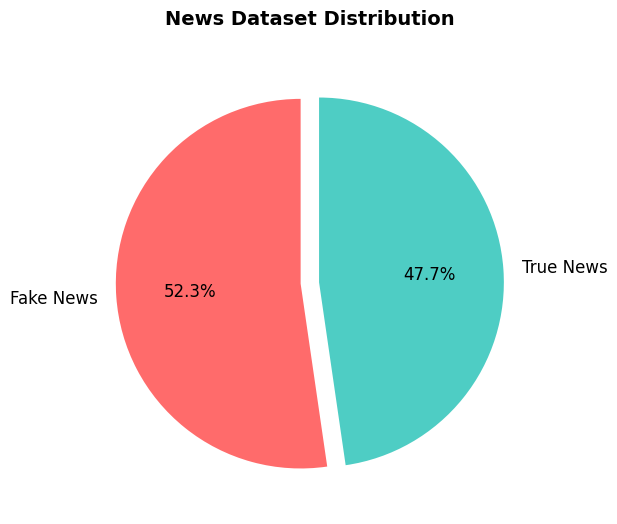

In [41]:
import matplotlib.pyplot as plt

# Create pie chart
categories = ['Fake News', 'True News']
counts = [len(fakenews), len(truenews)]
colors = ['#ff6b6b', '#4ecdc4']

plt.figure(figsize=(8, 6))
plt.pie(counts, labels=categories, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=(0.05, 0.05), textprops={'fontsize': 12})

plt.title('News Dataset Distribution', fontsize=14, fontweight='bold', pad=20)
plt.show()

In [42]:
# Label datasets (0 = Fake, 1 = Real)
fakenews['label'] = 0
truenews['label'] = 1

In [43]:
# Remove unnecessary columns
cols_to_drop = ['title', 'subject', 'date']
truenews.drop(columns=cols_to_drop, inplace=True)
fakenews.drop(columns=cols_to_drop, inplace=True)

In [44]:
# Combine and shuffle datasets
News = pd.concat([fakenews, truenews], ignore_index=True)
News = News.sample(frac=1, random_state=42).reset_index(drop=True)

In [45]:
# Check for duplicates
duplicate_count = News.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count:,}")

# Remove duplicates
News.drop_duplicates(inplace=True)

# Verify duplicates after removal
remaining_duplicates = News.duplicated().sum()
print(f"Duplicates after removal: {remaining_duplicates:,}")
print(f"Records removed: {duplicate_count - remaining_duplicates:,}")
print(f"Dataset size after deduplication: {len(News):,} records")

Number of duplicate records: 6,251
Duplicates after removal: 0
Records removed: 6,251
Dataset size after deduplication: 38,647 records


In [46]:
# Define stopwords
stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation and digits
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Join back into a string
    cleaned_text = " ".join(tokens)
    return cleaned_text

# Apply the cleaning function to the 'text' column
News['text'] = News['text'].apply(clean_text)

In [48]:
# Train-test split
X = News['text']
y = News['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Test set total: {len(X_test)}")
print(f"Test Fake (0): {sum(y_test==0)}")
print(f"Test Real (1): {sum(y_test==1)}")

Test set total: 7730
Test Fake (0): 3495
Test Real (1): 4235


# =============================================
# SECTION 3: LSTM MODEL IMPLEMENTATION
# =============================================
"""
Deep Learning Approach:
- Uses Keras Tokenizer for text vectorization
- Implements a stacked LSTM architecture
- Includes dropout layers for regularization
- Trains with binary cross-entropy loss
"""

In [11]:
print("\nTraining LSTM Model...")

max_words = 10000
max_len = 500

# Tokenization and padding
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(Embedding(max_words, 128, input_length=max_len))
lstm_model.add(LSTM(128, return_sequences=True))
lstm_model.add(Dropout(0.3))
lstm_model.add(LSTM(64, return_sequences=False))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])

# Train the LSTM model
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)



Training LSTM Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.9300 - loss: 0.1853 - val_accuracy: 0.9526 - val_loss: 0.1338
Epoch 2/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9705 - loss: 0.0958 - val_accuracy: 0.9958 - val_loss: 0.0181
Epoch 3/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.9916 - loss: 0.0322 - val_accuracy: 0.9303 - val_loss: 0.1018
Epoch 4/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.9919 - loss: 0.0274 - val_accuracy: 0.9877 - val_loss: 0.0537
Epoch 5/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.9842 - loss: 0.0504 - val_accuracy: 0.9707 - val_loss: 0.0847
Epoch 6/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9956 - loss: 0.0163 - val_accuracy: 0.9956 - val_loss: 0.0200
Epoch 7/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.9983 - loss: 0.0065 - val_accuracy: 0.9977 - val_loss: 0.0127
Epoch 8/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9995 - loss: 0.0026 - 

# =============================================
# SECTION 4: LOGISTIC REGRESSION IMPLEMENTATION
# =============================================
"""
Traditional Machine Learning Approach:
- Uses TF-IDF for feature extraction
- Implements logistic regression classifier
- Serves as baseline for comparison
"""


In [12]:
# =============================================
# Logistic Regression Implementation
# =============================================
print("\nTraining Logistic Regression Model...")

# Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)



Training Logistic Regression Model...


LogisticRegression(max_iter=1000, random_state=42)

# =============================================
# SECTION 5: MODEL EVALUATION AND COMPARISON
# =============================================
"""
Performance Analysis:
- Accuracy metrics for both models
- Confusion matrices
- Classification reports
- Visual comparison
"""

242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9974 - loss: 0.0367
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
LSTM Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      3495
        Real       1.00      1.00      1.00      4235

    accuracy                           1.00      7730
   macro avg       1.00      1.00      1.00      7730
weighted avg       1.00      1.00      1.00      7730


Logistic Regression Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      3495
        Real       0.99      0.99      0.99      4235

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730


MODEL PERFORMANCE COMPARISON
LSTM Accuracy: 0.9974
Logistic Regression Accuracy: 0.9895


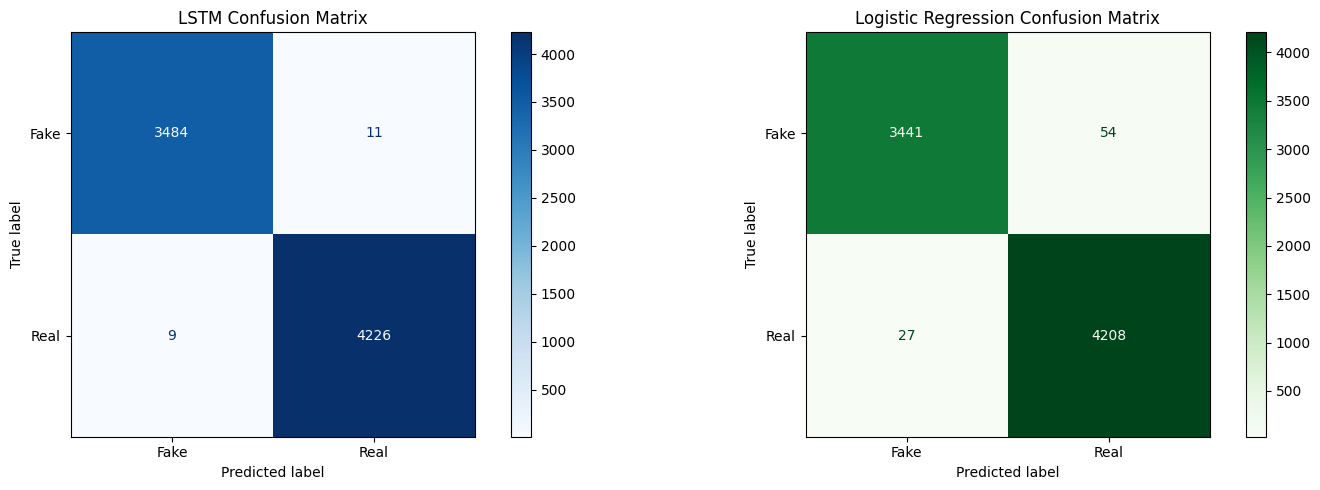

In [13]:
# LSTM Evaluation
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_pad, y_test)
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")

# Classification Report
print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=["Fake", "Real"]))

# Evaluate Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

# Logistic Regression Classification Report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["Fake", "Real"]))

# Performance comparison
print("\nMODEL PERFORMANCE COMPARISON")
print("============================")
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LSTM Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lstm,
    display_labels=['Fake', 'Real'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('LSTM Confusion Matrix')

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Fake', 'Real'],
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title('Logistic Regression Confusion Matrix')

plt.tight_layout()
plt.show()

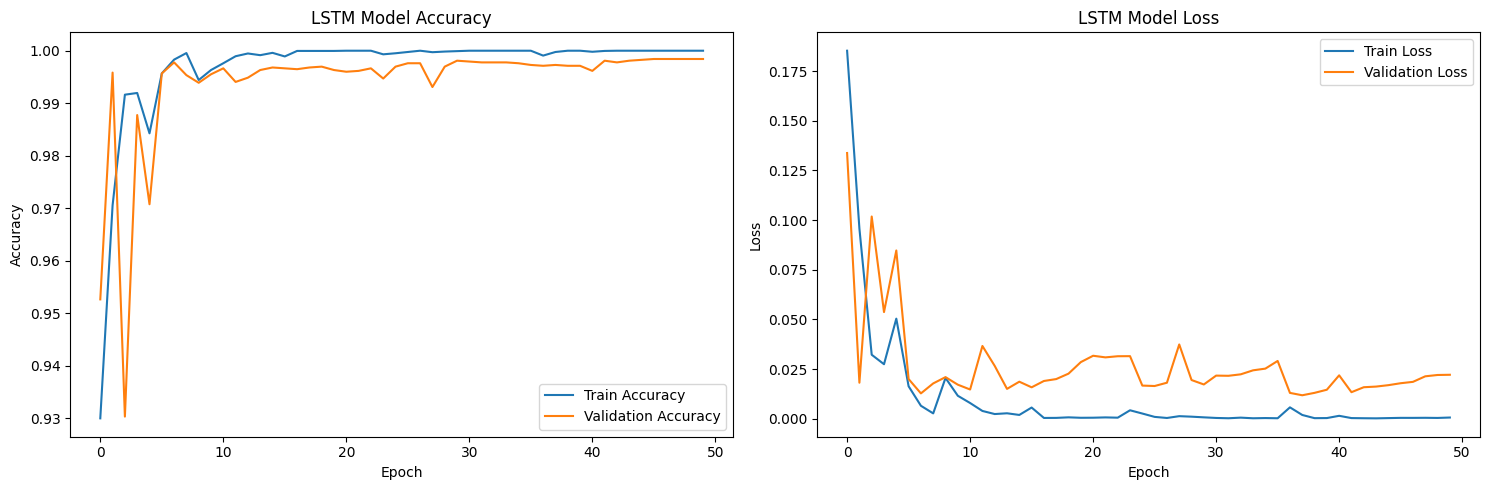

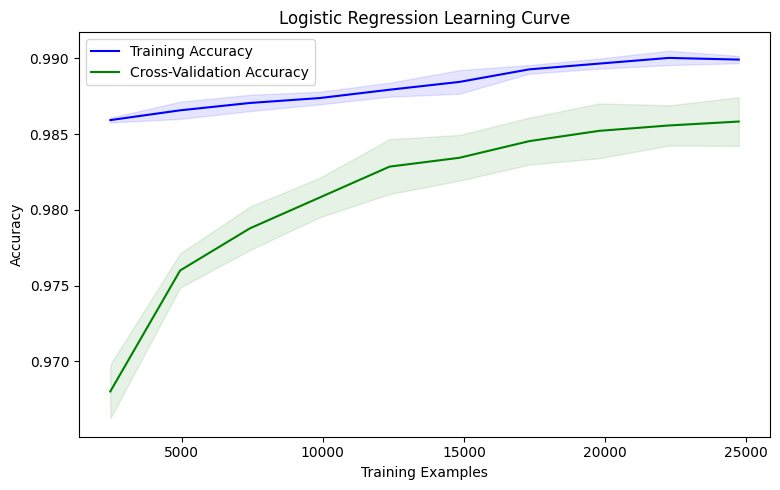

In [14]:
# LSTM TRAINING HISTORY VISUALIZATION

plt.figure(figsize=(15, 5))

# LSTM Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# LSTM Loss Plot
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# LOGISTIC REGRESSION LEARNING CURVE VISUALIZATION
from sklearn.model_selection import learning_curve

# Create a figure for Logistic Regression metrics
plt.figure(figsize=(15, 5))

# Get learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=1000),
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Logistic Regression Learning Curve
plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, label='Cross-Validation Accuracy', color='green')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
plt.title('Logistic Regression Learning Curve')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

# =============================================
# SECTION 6: PRACTICAL TESTING INTERFACE
# =============================================
"""
Sample Testing Functionality:
- Tests both models on user-provided text
- Shows confidence scores
- Handles both short and long articles
"""

In [28]:
def predict_news(text, show_text=True):
    """Test a news article with both models"""
    # Clean the input text
    cleaned_text = clean_text(text)

    # LSTM Prediction
    seq = tokenizer.texts_to_sequences([cleaned_text])
    pad = pad_sequences(seq, maxlen=max_len)
    lstm_prob = lstm_model.predict(pad)[0][0]
    lstm_label = "REAL" if lstm_prob > 0.5 else "FAKE"
    lstm_confidence = max(lstm_prob, 1 - lstm_prob)

    # Logistic Regression Prediction
    tfidf = vectorizer.transform([cleaned_text])
    lr_prob = lr_model.predict_proba(tfidf)[0][1]
    lr_label = "REAL" if lr_prob > 0.5 else "FAKE"
    lr_confidence = max(lr_prob, 1 - lr_prob)

    # Display results
    print("NEWS CLASSIFICATION RESULTS")

    if show_text:
        print("\nArticle Preview:")
        print(text[:300] + ("..." if len(text) > 300 else ""))

    print("\nLSTM Model Prediction:")
    print(f"- Classification: {lstm_label}")
    print(f"- Confidence: {lstm_confidence*100:.2f}%")

    print("\nLogistic Regression Prediction:")
    print(f"- Classification: {lr_label}")
    print(f"- Confidence: {lr_confidence*100:.2f}%")
    print("="*50 + "\n")

# Sample test cases
fake_example = """
BREAKING: Apple announces new iPhone will charge through human body heat!
The revolutionary technology uses skin contact to power devices indefinitely.
Starting with iPhone 16, no more charging cables needed.
"""

real_example = """
On Wednesday, Trump’s budget chief Mick Mulvaney and legislative affairs director Marc Short will meet with Senate
Majority Leader Mitch McConnell and House Speaker Paul Ryan - both Republicans - and their Democratic counterparts, Senator
Chuck Schumer and Representative Nancy Pelosi, the White House said. That will be followed up with a weekend of strategy sessions
for Trump, McConnell and Ryan on Jan. 6 and 7 at the Camp David presidential retreat in Maryland, according to the White House.
The Senate returns to work on Jan.
"""

# Execute tests
print("\nTESTING FAKE NEWS EXAMPLE")
predict_news(fake_example)

print("\nTESTING REAL NEWS EXAMPLE")
predict_news(real_example)


TESTING FAKE NEWS EXAMPLE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
NEWS CLASSIFICATION RESULTS

Article Preview:

BREAKING: Apple announces new iPhone will charge through human body heat!
The revolutionary technology uses skin contact to power devices indefinitely.
Starting with iPhone 16, no more charging cables needed.


LSTM Model Prediction:
- Classification: FAKE
- Confidence: 100.00%

Logistic Regression Prediction:
- Classification: FAKE
- Confidence: 71.85%


TESTING REAL NEWS EXAMPLE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
NEWS CLASSIFICATION RESULTS

Article Preview:

On Wednesday, Trump’s budget chief Mick Mulvaney and legislative affairs director Marc Short will meet with Senate 
Majority Leader Mitch McConnell and House Speaker Paul Ryan - both Republicans - and their Democratic counterparts, Senator
Chuck Schumer and Representative Nancy Pelosi, the White Ho...

LSTM Model Prediction:
- Classification: REAL
- Confidence: 100.00%

Logistic Regression Prediction:
- Classifica

# =============================================
# SECTION 7: MODEL PERSISTENCE
# =============================================
# Save models for future use

In [16]:
lstm_model.save("fake_news_lstm_model.h5")

import joblib
joblib.dump(lr_model, 'fake_news_lr_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("\nAll models saved successfully for deployment!")


All models saved successfully for deployment!
